# Análisis Exploratorio

Este notebook realiza un análisis exploratorio de los datos de tráfico y emisiones contaminantes, seguido de la creación de un pipeline utilizando Hugging Face.

### Objetivos
- [x] Realizar un EDA (Análisis Exploratorio de Datos).
- [x] Preprocesar los datos y realizar imputación de valores nulos.
- [ ] Crear un pipeline con Hugging Face para predicción o clasificación.
- [ ] Explorar el TabTransformer


In [2]:
# Importar bibliotecas necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from transformers import pipeline

In [3]:
# Cargar los datos de los archivos CSV
trafico_feb22_ago23 = pd.read_csv('../data/trafico_feb22_ago23.csv')
from pprint import pprint
pprint(list(trafico_feb22_ago23.columns))

['date',
 'vehicles_CAP_OUT',
 'vehicles_CAP_OUT_Zona_Granada',
 'vehicles_CAP_OUT_Zona_Catalunia_y_Otras',
 'vehicles_CAP_OUT_Zona_Andalucia_no_GR',
 'vehicles_CAP_OUT_Extranjero',
 'vehicles_CAP_OUT_Zona_Comunidad_de_Madrid',
 'vehicles_CAP_OUT_Zona_Extremadura_y_Otras',
 'vehicles_CAP_OUT_Zona_Otras',
 'vehicles_CAP_OUT_5_seats',
 'vehicles_CAP_OUT_+5_seats',
 'vehicles_CAP_OUT_-5_seats',
 'vehicles_CAP_OUT_nan_seats',
 'vehicles_CAP_OUT_101-200_CO2',
 'vehicles_CAP_OUT_0-100_CO2',
 'vehicles_CAP_OUT_nan_CO2',
 'vehicles_CAP_OUT_201-300_CO2',
 'vehicles_CAP_OUT_+300_CO2',
 'vehicles_CAP_IN',
 'vehicles_CAP_IN_Zona_Granada',
 'vehicles_CAP_IN_Zona_Catalunia_y_Otras',
 'vehicles_CAP_IN_Zona_Andalucia_no_GR',
 'vehicles_CAP_IN_Extranjero',
 'vehicles_CAP_IN_Zona_Comunidad_de_Madrid',
 'vehicles_CAP_IN_Zona_Extremadura_y_Otras',
 'vehicles_CAP_IN_Zona_Otras',
 'vehicles_CAP_IN_5_seats',
 'vehicles_CAP_IN_+5_seats',
 'vehicles_CAP_IN_-5_seats',
 'vehicles_CAP_IN_nan_seats',
 'vehicles_CA

In [4]:
trafico_feb22_ago23.head()

,date,vehicles_CAP_OUT,vehicles_CAP_OUT_Zona_Granada,vehicles_CAP_OUT_Zona_Catalunia_y_Otras,vehicles_CAP_OUT_Zona_Andalucia_no_GR,vehicles_CAP_OUT_Extranjero,vehicles_CAP_OUT_Zona_Comunidad_de_Madrid,vehicles_CAP_OUT_Zona_Extremadura_y_Otras,vehicles_CAP_OUT_Zona_Otras,vehicles_CAP_OUT_5_seats,...,vehicles_BUB_IN_Zona_Otras,vehicles_BUB_IN_5_seats,vehicles_BUB_IN_+5_seats,vehicles_BUB_IN_-5_seats,vehicles_BUB_IN_nan_seats,vehicles_BUB_IN_101-200_CO2,vehicles_BUB_IN_0-100_CO2,vehicles_BUB_IN_nan_CO2,vehicles_BUB_IN_201-300_CO2,vehicles_BUB_IN_+300_CO2
0,2022-02-04 12:00:00+00:00,23,11,1,2,5,2,2,0,12,...,0,0,0,0,0,0,0,0,0,0
1,2022-02-04 13:00:00+00:00,25,11,1,4,7,2,0,0,10,...,0,0,0,0,0,0,0,0,0,0
2,2022-02-04 14:00:00+00:00,32,20,1,6,4,1,0,0,23,...,0,0,0,0,0,0,0,0,0,0
3,2022-02-04 15:00:00+00:00,32,20,1,6,2,2,1,0,24,...,0,0,0,0,0,0,0,0,0,0
4,2022-02-04 16:00:00+00:00,30,11,1,8,3,3,4,0,22,...,0,0,0,0,0,0,0,0,0,0


In [5]:
trafico_contamina_interseccion = pd.read_csv('../data/trafico_contamina_intersección.csv')

pprint(list(trafico_contamina_interseccion.columns))

['Date',
 'CO',
 'NO2',
 'NO',
 'O3',
 'SO2',
 'PM10',
 'eBC_tot',
 'eBC_ff',
 'eBC_bb',
 'TEMP',
 'RH',
 'WS',
 'WD',
 'PRES',
 'truck_pos',
 'eBC',
 'vehicles_PAM_1_OUT',
 'vehicles_PAM_1_OUT_Zona_Granada',
 'vehicles_PAM_1_OUT_Zona_Comunidad_de_Madrid',
 'vehicles_PAM_1_OUT_Extranjero',
 'vehicles_PAM_1_OUT_Zona_Andalucia_no_GR',
 'vehicles_PAM_1_OUT_Zona_Catalunia_y_Otras',
 'vehicles_PAM_1_OUT_Zona_Extremadura_y_Otras',
 'vehicles_PAM_1_OUT_Zona_Otras',
 'vehicles_PAM_1_OUT_5_seats',
 'vehicles_PAM_1_OUT_nan_seats',
 'vehicles_PAM_1_OUT_+5_seats',
 'vehicles_PAM_1_OUT_-5_seats',
 'vehicles_PAM_1_OUT_101-200_CO2',
 'vehicles_PAM_1_OUT_nan_CO2',
 'vehicles_PAM_1_OUT_+300_CO2',
 'vehicles_PAM_1_OUT_0-100_CO2',
 'vehicles_PAM_1_OUT_201-300_CO2',
 'vehicles_PAM_1_OUT_Etiqueta C',
 'vehicles_PAM_1_OUT_Sin Etiqueta',
 'vehicles_PAM_1_OUT_Etiqueta B',
 'vehicles_PAM_1_OUT_Etiqueta ECO',
 'vehicles_PAM_1_OUT_Etiqueta 0',
 'vehicles_PAM_1_IN',
 'vehicles_PAM_1_IN_Zona_Granada',
 'vehicles_P

In [6]:
trafico_contamina_interseccion.head()

,Date,CO,NO2,NO,O3,SO2,PM10,eBC_tot,eBC_ff,eBC_bb,...,vehicles_BUB_IN_101-200_CO2,vehicles_BUB_IN_nan_CO2,vehicles_BUB_IN_+300_CO2,vehicles_BUB_IN_0-100_CO2,vehicles_BUB_IN_201-300_CO2,vehicles_BUB_IN_Etiqueta C,vehicles_BUB_IN_Sin Etiqueta,vehicles_BUB_IN_Etiqueta B,vehicles_BUB_IN_Etiqueta ECO,vehicles_BUB_IN_Etiqueta 0
0,2022-11-16 16:00:00,0.39,3.8,0.4,71.6,NaN,NaN,0.3,0.2,0.1,...,10,11,1,4,0,8,6,8,3,1
1,2022-11-16 17:00:00,0.50,2.9,0.1,68.4,NaN,NaN,0.1,0.0,0.1,...,6,8,0,1,1,5,7,3,1,0
2,2022-11-16 18:00:00,0.29,4.4,0.6,62.8,NaN,NaN,0.6,0.1,0.5,...,0,0,0,0,0,0,0,0,0,0
3,2022-11-16 19:00:00,0.26,5.0,0.8,62.3,NaN,NaN,0.9,0.0,0.9,...,0,0,0,0,0,0,0,0,0,0
4,2022-11-16 20:00:00,0.20,3.8,0.5,60.1,NaN,NaN,0.6,0.2,0.4,...,0,0,0,0,0,0,0,0,0,0


In [7]:
set(trafico_contamina_interseccion["truck_pos"])

{'CAP', 'PAM_2'}

## Periodo del camión de meteorología en las regiones

### Capileira 
- 16/11/2022-15/01/2023

### Pampaneira
- 17/01/2023-14/03/2023
- 06/06/2023-27/06/2023

In [8]:
trafico_contamina_interseccion["Date"] = pd.to_datetime(trafico_contamina_interseccion["Date"])

In [9]:
fechas_cap = trafico_contamina_interseccion[trafico_contamina_interseccion["truck_pos"] == "CAP"]["Date"]
trafico_cap = trafico_contamina_interseccion[trafico_contamina_interseccion["truck_pos"] == "CAP"]
trafico_pam = trafico_contamina_interseccion[trafico_contamina_interseccion["truck_pos"] == "PAM_2"] 

fecha_filtro = pd.to_datetime("2023-06-06")
trafico_pam_periodo1 = trafico_pam[trafico_pam["Date"] < fecha_filtro]
trafico_pam_periodo2 = trafico_pam[trafico_pam["Date"] >= fecha_filtro]

fechas_pam_periodo1 = trafico_pam_periodo1["Date"]
fechas_pam_periodo2 = trafico_pam_periodo2["Date"]

In [10]:
from datetime import datetime, timedelta

def obtener_dias_faltantes(fecha_lista):
    # Convertir las cadenas de fecha a objetos datetime y obtener solo las fechas
    fechas = [fecha.date() for fecha in fecha_lista]

    # Determinar el rango de fechas
    fecha_inicio = min(fechas)
    fecha_fin = max(fechas)

    # Generar todos los días en el rango
    todos_los_dias = set(fecha_inicio + timedelta(days=i) for i in range((fecha_fin - fecha_inicio).days + 1))

    # Convertir la lista de fechas a un conjunto para la comparación
    fechas_set = set(fechas)

    # Calcular los días faltantes
    dias_faltantes = todos_los_dias - fechas_set

    return sorted(dias_faltantes)

In [11]:
dias_faltantes_cap = obtener_dias_faltantes(fechas_cap)
dias_faltantes_pam_periodo1 = obtener_dias_faltantes(fechas_pam_periodo1)
dias_faltantes_pam_periodo2 = obtener_dias_faltantes(fechas_pam_periodo2)

print("Capileira: 16/11/2022-15/01/2023")
print("Días faltantes: ")
for dia_faltante_cap in dias_faltantes_cap:
    print(f"* {dia_faltante_cap}")

print("\nPampaneira: 17/01/2023-14/03/2023")
print("Días faltantes: ")
for dia_faltante_pam in dias_faltantes_pam_periodo1:
    print(f"* {dia_faltante_pam}")

print("\nPampaneira: 06/06/2023-27/06/2023")
print("Días faltantes: ")
for dia_faltante_pam in dias_faltantes_pam_periodo2:
    print(f"* {dia_faltante_pam}")

Capileira: 16/11/2022-15/01/2023
Días faltantes: 
* 2022-12-30
* 2022-12-31
* 2023-01-01
* 2023-01-02
* 2023-01-03
* 2023-01-04
* 2023-01-05
* 2023-01-06
* 2023-01-07
* 2023-01-08
* 2023-01-09
* 2023-01-10

Pampaneira: 17/01/2023-14/03/2023
Días faltantes: 

Pampaneira: 06/06/2023-27/06/2023
Días faltantes: 
* 2023-06-11


In [12]:
import pandas as pd

mean_values = trafico_contamina_interseccion.select_dtypes(include='number').mean()

# Ajustar la configuración para mostrar todas las filas y columnas
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
print("Medias - Columnas: ")
print(mean_values)

Medias - Columnas: 
CO                                               0.192576
NO2                                              4.153839
NO                                               0.765554
O3                                              74.185321
SO2                                              0.855969
PM10                                            18.369377
eBC_tot                                          0.489836
eBC_ff                                           0.325452
eBC_bb                                           0.132579
TEMP                                            10.614455
RH                                              58.498436
WS                                               1.611853
WD                                             157.230044
PRES                                           877.623671
eBC                                              0.442909
vehicles_PAM_1_OUT                               9.714745
vehicles_PAM_1_OUT_Zona_Granada                  4.3

### Realizar interpolación para datos concretos de horas

## Cantidad de elementos por truck_pos

/var/folders/gn/9s3465fs47zbr19dkkb4dxwh0000gn/T/ipykernel_63216/1358990316.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


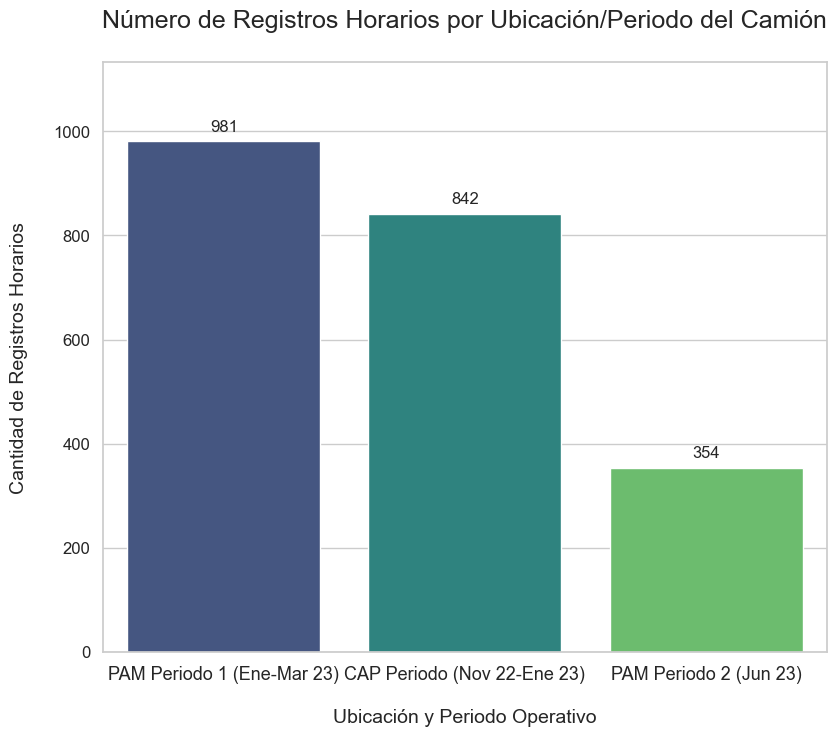

In [13]:
# Crear un DataFrame combinado
trafico_combined = pd.DataFrame({
    'truck_pos': ['PAM Periodo 1 (Ene-Mar 23)'] * len(trafico_pam_periodo1) + \
                 ['PAM Periodo 2 (Jun 23)'] * len(trafico_pam_periodo2) + \
                 ['CAP Periodo (Nov 22-Ene 23)'] * len(trafico_cap),
    'Date': pd.concat([trafico_pam_periodo1['Date'],
                       trafico_pam_periodo2['Date'],
                       trafico_cap['Date']
                       ], ignore_index=True)
})

# Contar los elementos por tipo de camión/periodo
counts = trafico_combined['truck_pos'].value_counts().reset_index()
counts.columns = ['Ubicacion_Periodo', 'Numero_Registros']

# Ordenar los datos (opcional: por cantidad descendente)
counts = counts.sort_values('Numero_Registros', ascending=False)

# --- Mejoras para el Gráfico con Barras Relativamente Más Estrechas ---

# 1. Establecer un tema de Seaborn
sns.set_theme(style="whitegrid")

# 2. Crear la figura y los ejes, AJUSTANDO EL ANCHO
# Reducir el ancho relativo a la altura hará que las barras sean más estrechas
plt.figure(figsize=(9, 8)) # Reducido ancho (antes 11), mantenido alto

# 3. Crear el gráfico de barras
# Nota: El ancho real de la barra lo calcula Seaborn/Matplotlib automáticamente
# basado en el número de categorías y el espacio disponible.
ax = sns.barplot(
    x='Ubicacion_Periodo',
    y='Numero_Registros',
    data=counts,
    palette='viridis',
    legend=False
    # No hay un parámetro 'width' directo fácil en sns.barplot para controlar esto
)

# 4. Añadir etiquetas de datos (manteniendo tamaño grande)
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', padding=5, fontsize=12)

# 5. Añadir título y etiquetas de ejes (manteniendo tamaño grande)
plt.title('Número de Registros Horarios por Ubicación/Periodo del Camión', fontsize=18, pad=25)
plt.xlabel('Ubicación y Periodo Operativo', fontsize=14, labelpad=18)
plt.ylabel('Cantidad de Registros Horarios', fontsize=14, labelpad=18)

# 6. Ajustar las etiquetas de los ejes (manteniendo tamaño grande)
# Si las etiquetas del eje X se solapan por reducir el ancho, podríamos rotarlas
plt.xticks(fontsize=13) # Considera rotar si es necesario: rotation=30, ha='right'
plt.yticks(fontsize=12)

# 7. Ajustar los límites del eje Y
current_ylim = ax.get_ylim()
ax.set_ylim(current_ylim[0], current_ylim[1] * 1.10)

# 8. Ajustar el diseño
plt.tight_layout(pad=2.5)

# 9. Mostrar el gráfico
plt.show()


**TODO: Interpolación para completar los valores nulos.**

Se puede aprovechar teoría de Métodos Numéricos -> Splines 

## Porcentajes de valores nulos en cada columna

NameError: name 'mtick' is not defined

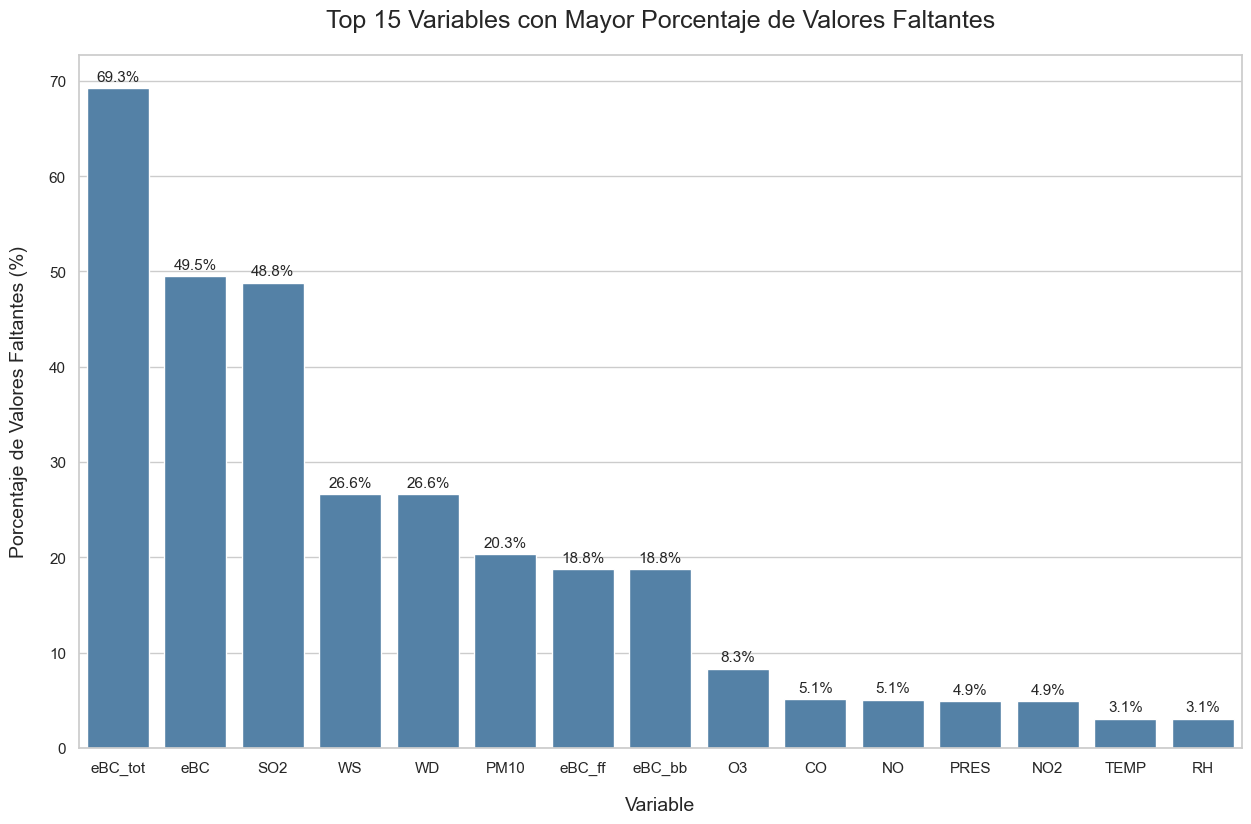

In [14]:

# Se crea un diccionario con clave el nombre de las columnas,
# y values el porcentaje de datos perdidos
nan_count = {k:list(trafico_contamina_interseccion.isna().sum()*100/trafico_contamina_interseccion.shape[0])[i] for i,k in enumerate(trafico_contamina_interseccion.columns)}

# Se ordena el diccionario en orden descendente
nan_count = {k: v for k, v in sorted(nan_count.items(), key=lambda item: item[1],reverse=True)}

# --- Preparación del DataFrame para el Plot (Top 15) ---
top_n = 15
data_plot = pd.DataFrame({
    'Características': list(nan_count.keys())[:top_n],
    'Porcentaje': list(nan_count.values())[:top_n]
    # No necesitamos la columna 'Grupo' ficticia
})

# --- Mejoras para el Gráfico ---

# 1. Establecer tema de Seaborn
sns.set_theme(style="whitegrid")

# 2. Crear figura y ejes con tamaño más proporcionado
# Más alto y ligeramente menos ancho que el original para acomodar etiquetas rotadas
plt.figure(figsize=(15, 9)) # Ajusta según necesidad

# 3. Crear gráfico de barras (sin hue, color único o paleta simple)
# Usaremos un color específico para evitar la complejidad de la paleta con una sola serie
ax = sns.barplot(
    x='Características',
    y='Porcentaje',
    data=data_plot,
    color='steelblue', # Un color sólido y claro
    # palette="viridis" # Alternativa si prefieres una paleta
    legend=False      # No hay hue, no necesita leyenda
)

# 4. Añadir etiquetas de datos encima de las barras
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.1f%%',       # Formato: número con 1 decimal y '%'
        label_type='edge',  # Posición de la etiqueta
        padding=3,          # Espacio sobre la barra
        fontsize=11         # Tamaño de fuente ligeramente mayor
    )

# 5. Añadir Título y Etiquetas de Ejes claros y más grandes
plt.title(f'Top {top_n} Variables con Mayor Porcentaje de Valores Faltantes', fontsize=18, pad=20)
plt.xlabel('Variable', fontsize=14, labelpad=15)
plt.ylabel('Porcentaje de Valores Faltantes (%)', fontsize=14, labelpad=15)

# 6. Formatear el eje Y para mostrar porcentajes claramente
# Usar PercentFormatter para mejor espaciado y formato automático
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100.0))
# Ajustar tamaño de fuente de los ticks del eje Y
plt.yticks(fontsize=12)

# 7. Rotar y alinear las etiquetas del eje X para evitar solapamiento
plt.xticks(
    rotation=45,         # Rotar etiquetas
    ha='right',          # Alinear a la derecha para mejor lectura con rotación
    rotation_mode='anchor', # Modo de rotación
    fontsize=12          # Tamaño de fuente ligeramente mayor
)

# 8. Ajustar límites del eje Y para dar espacio a las etiquetas de las barras
current_ylim = ax.get_ylim()
# Asegurar que el límite inferior sea 0 (o ligeramente menos) y el superior tenga margen
ax.set_ylim(0, max(data_plot['Porcentaje']) * 1.12) # 12% de margen superior

# 9. Ajustar el layout general para evitar solapamientos
plt.tight_layout(pad=2.0)

# 10. Mostrar el gráfico
plt.show()


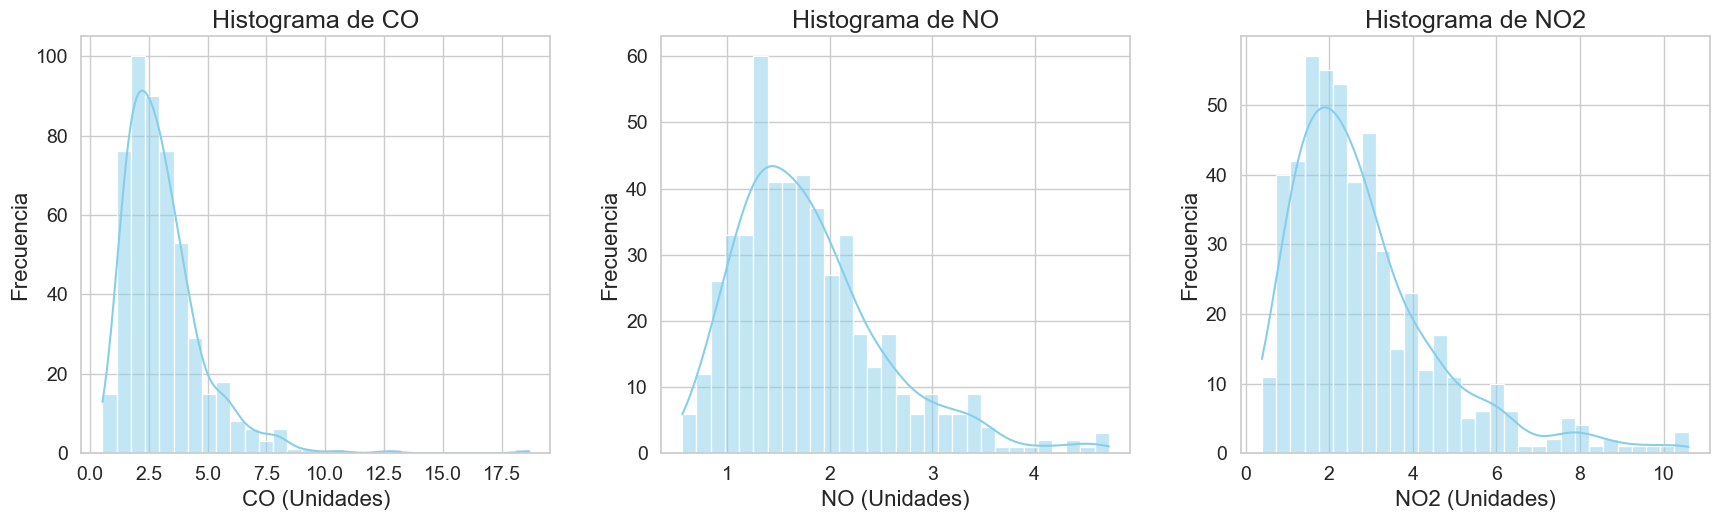

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd  # Necesario para crear datos de ejemplo
import numpy as np   # Necesario para crear datos de ejemplo

# --- Creación de Datos de Ejemplo ---
# Como no tenemos el DataFrame 'trafico_contamina_interseccion', creamos uno simulado.
# Reemplaza esto con tu DataFrame real cuando uses el código.
np.random.seed(42) # Para reproducibilidad
data = {
    'CO': np.random.lognormal(mean=1, sigma=0.5, size=500),
    'NO': np.random.lognormal(mean=0.5, sigma=0.4, size=500),
    'NO2': np.random.lognormal(mean=0.8, sigma=0.6, size=500)
}
trafico_contamina_interseccion = pd.DataFrame(data)
# --- Fin de Datos de Ejemplo ---


variables_contaminacion = ['CO', 'NO', 'NO2']

# Define los tamaños de fuente deseados
TITLE_FONTSIZE = 18  # Tamaño para los títulos de los subplots
LABEL_FONTSIZE = 16  # Tamaño para las etiquetas de los ejes (X e Y)
TICK_FONTSIZE = 14   # Tamaño opcional para los números en los ejes (ticks)

# Histograma para CO, NO, NO2
plt.figure(figsize=(18, 6)) # Ajusta el tamaño general si es necesario para acomodar texto más grande

for i, variable in enumerate(variables_contaminacion):
    # Selecciona el subplot actual
    ax = plt.subplot(1, 3, i+1) # Guardamos la referencia al eje (Axes object)

    # Crea el histograma
    sns.histplot(trafico_contamina_interseccion[variable], bins=30, kde=True, color='skyblue', ax=ax)

    # Establece el título con tamaño de fuente personalizado
    ax.set_title(f'Histograma de {variable}', fontsize=TITLE_FONTSIZE)

    # Establece la etiqueta del eje X con tamaño de fuente personalizado
    ax.set_xlabel(f'{variable} (Unidades)', fontsize=LABEL_FONTSIZE)

    # Establece la etiqueta del eje Y con tamaño de fuente personalizado
    ax.set_ylabel('Frecuencia', fontsize=LABEL_FONTSIZE)

    # Opcional: Ajusta el tamaño de los números en los ejes (ticks)
    ax.tick_params(axis='both', which='major', labelsize=TICK_FONTSIZE)

# Ajusta el layout para evitar solapamientos
plt.tight_layout(pad=3.0) # Añadir un poco más de padding si tight_layout por sí solo no es suficiente

# Muestra el plot
plt.show()

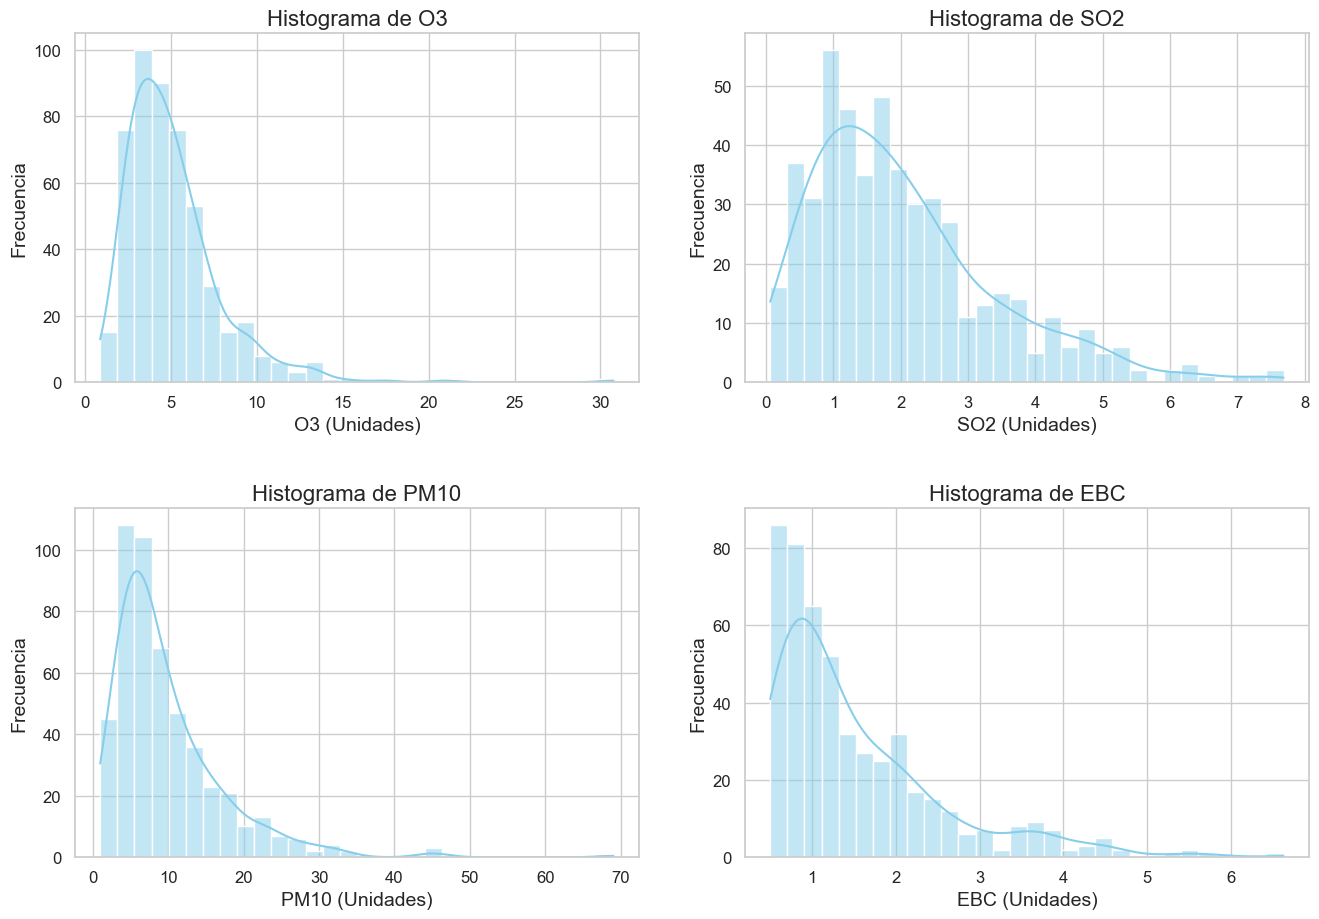

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd  # Necesario para crear datos de ejemplo
import numpy as np   # Necesario para crear datos de ejemplo

# --- Creación de Datos de Ejemplo ---
# Como no tenemos el DataFrame 'trafico_contamina_interseccion', creamos uno simulado
# con las nuevas variables ('O3', 'SO2', 'PM10', 'EBC').
# Reemplaza esto con tu DataFrame real cuando uses el código.
np.random.seed(42) # Para reproducibilidad
data = {
    'O3': np.random.lognormal(mean=1.5, sigma=0.5, size=500),
    'SO2': np.random.gamma(shape=2., scale=1.0, size=500), # Usando otra distribución para variar
    'PM10': np.random.lognormal(mean=2, sigma=0.7, size=500),
    'EBC': np.random.exponential(scale=1.0, size=500) + 0.5 # Usando otra distribución
}
trafico_contamina_interseccion = pd.DataFrame(data)
# --- Fin de Datos de Ejemplo ---


# Lista actualizada de variables
variables_contaminacion = ['O3', 'SO2', 'PM10', "EBC"]

# Define los tamaños de fuente deseados (puedes ajustarlos)
TITLE_FONTSIZE = 16  # Tamaño para los títulos de los subplots
LABEL_FONTSIZE = 14  # Tamaño para las etiquetas de los ejes (X e Y)
TICK_FONTSIZE = 12   # Tamaño para los números en los ejes (ticks)

# --- Creación del Plot 2x2 ---

# Ajusta el tamaño de la figura para que quepa bien una cuadrícula 2x2
plt.figure(figsize=(14, 10)) # Más alto que ancho para 2x2

# Itera sobre las variables y sus índices
for i, variable in enumerate(variables_contaminacion):
    # Calcula la posición en la cuadrícula 2x2
    # i+1 es el número de subplot (1, 2, 3, 4)
    ax = plt.subplot(2, 2, i+1) # <--- CAMBIO CLAVE: 2 filas, 2 columnas

    # Verifica si la variable existe en el DataFrame antes de intentar plotearla
    if variable in trafico_contamina_interseccion.columns:
        # Crea el histograma
        sns.histplot(trafico_contamina_interseccion[variable], bins=30, kde=True, color='skyblue', ax=ax)

        # Establece el título con tamaño de fuente personalizado
        ax.set_title(f'Histograma de {variable}', fontsize=TITLE_FONTSIZE)

        # Establece la etiqueta del eje X con tamaño de fuente personalizado
        ax.set_xlabel(f'{variable} (Unidades)', fontsize=LABEL_FONTSIZE)

        # Establece la etiqueta del eje Y con tamaño de fuente personalizado
        ax.set_ylabel('Frecuencia', fontsize=LABEL_FONTSIZE)

        # Ajusta el tamaño de los números en los ejes (ticks)
        ax.tick_params(axis='both', which='major', labelsize=TICK_FONTSIZE)
    else:
        # Si la variable no existe, muestra un mensaje en el subplot
        ax.text(0.5, 0.5, f'Variable "{variable}"\nno encontrada',
                horizontalalignment='center', verticalalignment='center',
                fontsize=LABEL_FONTSIZE, color='red')
        ax.set_title(f'Error: {variable}', fontsize=TITLE_FONTSIZE)
        ax.set_xticks([]) # Oculta ejes si no hay datos
        ax.set_yticks([])


# Ajusta el layout para evitar solapamientos entre subplots
plt.tight_layout(pad=3.0) # El padding ayuda a separar títulos/etiquetas

# Muestra el plot
plt.show()

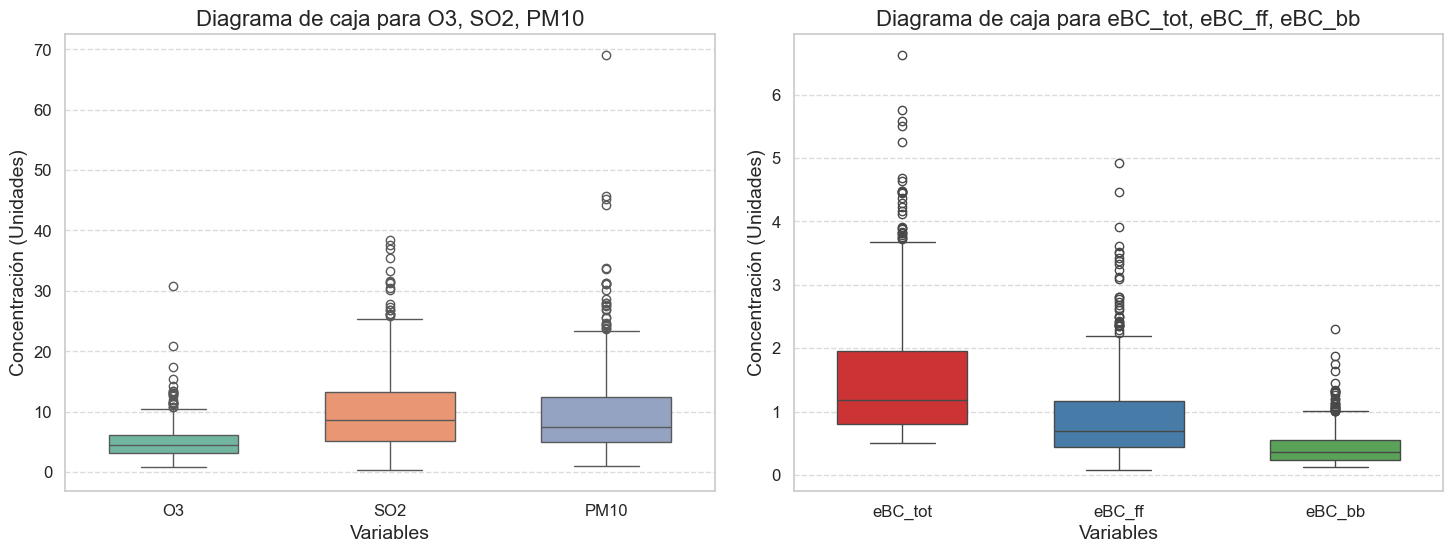

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- Creación de Datos de Ejemplo ---
# Asegúrate de que tu DataFrame 'trafico_contamina_interseccion' real
# contenga todas estas columnas.
np.random.seed(42) # Para reproducibilidad
data = {
    'O3': np.random.lognormal(mean=1.5, sigma=0.5, size=500),
    'SO2': np.random.gamma(shape=2., scale=1.0, size=500) * 5, # Escala diferente
    'PM10': np.random.lognormal(mean=2, sigma=0.7, size=500),
    'eBC_tot': np.random.exponential(scale=1.0, size=500) + 0.5,
    'eBC_ff': (np.random.exponential(scale=0.6, size=500) + 0.3) * (np.random.rand(500) * 0.5 + 0.5), # Simular fracción
    'eBC_bb': (np.random.exponential(scale=0.4, size=500) + 0.2) * (np.random.rand(500) * 0.5 + 0.5)  # Simular fracción
}
# Asegurar que ff + bb <= tot (aproximadamente)
data['eBC_ff'] = data['eBC_ff'] * data['eBC_tot'] / (data['eBC_ff'] + data['eBC_bb'] + 1e-6)
data['eBC_bb'] = data['eBC_bb'] * data['eBC_tot'] / (data['eBC_ff'] + data['eBC_bb'] + 1e-6)

trafico_contamina_interseccion = pd.DataFrame(data)
# --- Fin de Datos de Ejemplo ---


# --- Variables y Configuración ---
variables_contaminacion_boxplot = ['O3', 'SO2', 'PM10']
variables_contaminacion_ebc = ['eBC_tot', 'eBC_ff', 'eBC_bb']

# Define tamaños de fuente (opcional pero recomendado)
TITLE_FONTSIZE = 16
LABEL_FONTSIZE = 14
TICK_FONTSIZE = 12

# Ancho de los boxplots individuales (ajusta si se ven muy anchos o estrechos)
BOXPLOT_WIDTH = 0.6

# --- Creación del Plot con Subplots ---

# Crea una figura y un conjunto de subplots (1 fila, 2 columnas)
# figsize controla el tamaño total de la figura (ancho, alto en pulgadas)
# sharey=True hace que ambos gráficos compartan el mismo eje Y (si las escalas son comparables)
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=False) # Pon sharey=True si las escalas son similares

# --- Plot 1: O3, SO2, PM10 (Izquierda) ---
ax1 = axes[0] # Selecciona el primer eje (izquierda)
sns.boxplot(data=trafico_contamina_interseccion[variables_contaminacion_boxplot],
            palette='Set2',
            ax=ax1, # Especifica en qué eje dibujar
            width=BOXPLOT_WIDTH) # Ajusta el ancho de las cajas
ax1.set_title('Diagrama de caja para O3, SO2, PM10', fontsize=TITLE_FONTSIZE)
ax1.set_xlabel('Variables', fontsize=LABEL_FONTSIZE)
ax1.set_ylabel('Concentración (Unidades)', fontsize=LABEL_FONTSIZE) # Etiqueta Y general
ax1.tick_params(axis='both', which='major', labelsize=TICK_FONTSIZE)
ax1.grid(axis='y', linestyle='--', alpha=0.7) # Añadir rejilla puede ayudar

# --- Plot 2: eBC variables (Derecha) ---
ax2 = axes[1] # Selecciona el segundo eje (derecha)
sns.boxplot(data=trafico_contamina_interseccion[variables_contaminacion_ebc],
            palette='Set1',
            ax=ax2, # Especifica en qué eje dibujar
            width=BOXPLOT_WIDTH) # Ajusta el ancho de las cajas
ax2.set_title('Diagrama de caja para eBC_tot, eBC_ff, eBC_bb', fontsize=TITLE_FONTSIZE)
ax2.set_xlabel('Variables', fontsize=LABEL_FONTSIZE)
if not fig.get_constrained_layout(): # No poner etiqueta Y si se comparte el eje y tight_layout no está activo
     if not axes[0].get_shared_y_axes().joined(axes[0], axes[1]):
         ax2.set_ylabel('Concentración (Unidades)', fontsize=LABEL_FONTSIZE)
     else:
         ax2.set_ylabel('') # Ocultar etiqueta Y si se comparte el eje
         ax2.tick_params(axis='y', which='major', labelleft=False) # Ocultar ticks Y si se comparte
else: # Con layout constreñido, es más seguro ponerla o quitarla explícitamente
    if axes[0].get_shared_y_axes().joined(axes[0], axes[1]):
         ax2.set_ylabel('') # Ocultar etiqueta Y si se comparte el eje
         ax2.tick_params(axis='y', which='major', labelleft=False) # Ocultar ticks Y si se comparte
    else:
         ax2.set_ylabel('Concentración (Unidades)', fontsize=LABEL_FONTSIZE)


ax2.tick_params(axis='both', which='major', labelsize=TICK_FONTSIZE)
ax2.grid(axis='y', linestyle='--', alpha=0.7) # Añadir rejilla puede ayudar

# --- Ajustes Finales y Mostrar ---

# Ajusta automáticamente el layout para evitar solapamientos
plt.tight_layout(pad=2.0) # 'pad' añade un poco de espacio extra

# Muestra la figura con ambos plots
plt.show()

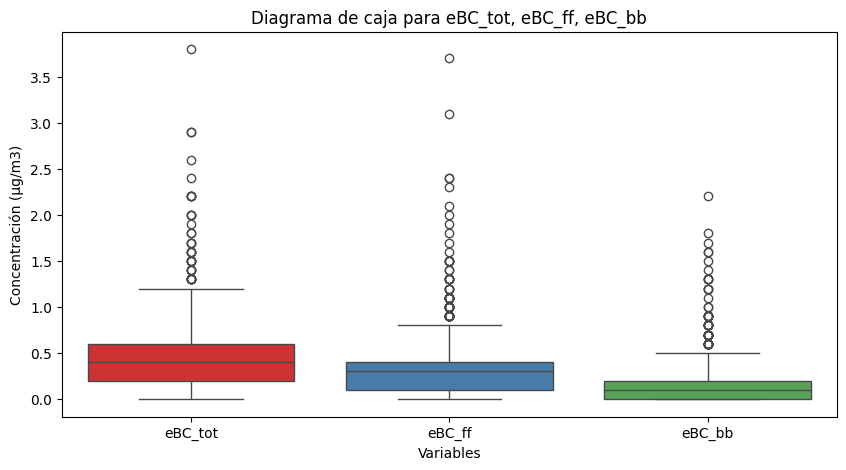

In [68]:
variables_contaminacion_ebc = ['eBC_tot', 'eBC_ff', 'eBC_bb']

# Diagrama de caja para eBC variables
plt.figure(figsize=(10, 5))
sns.boxplot(data=trafico_contamina_interseccion[variables_contaminacion_ebc], palette='Set1')
plt.title('Diagrama de caja para eBC_tot, eBC_ff, eBC_bb')
plt.xlabel('Variables')
plt.ylabel('Concentración (µg/m3)')
plt.show()

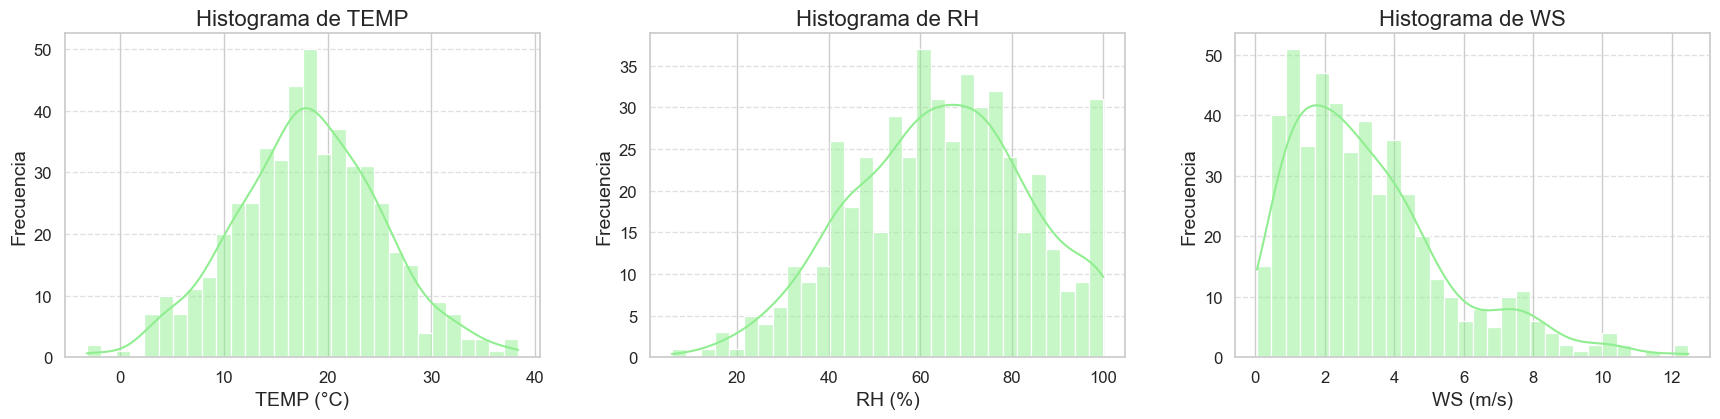

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# --- Creación de Datos de Ejemplo ---
# Añadimos TEMP, RH, WS al DataFrame de ejemplo.
# Asegúrate de que tu DataFrame 'trafico_contamina_interseccion' real
# contenga estas columnas con los nombres correctos.
np.random.seed(43) # Cambiamos la semilla para variar los datos meteorológicos
data = {
    # Datos meteorológicos
    'TEMP': np.random.normal(loc=18, scale=7, size=500), # Temperatura en °C (ejemplo)
    'RH': np.clip(np.random.normal(loc=65, scale=20, size=500), 0, 100), # Humedad Relativa en % (ejemplo)
    'WS': np.random.gamma(shape=2, scale=1.5, size=500), # Velocidad del viento en m/s (ejemplo)

    # Mantenemos los anteriores por si acaso, aunque no se usen en este plot
    'O3': np.random.lognormal(mean=1.5, sigma=0.5, size=500),
    'SO2': np.random.gamma(shape=2., scale=1.0, size=500) * 5,
    'PM10': np.random.lognormal(mean=2, sigma=0.7, size=500),
    'eBC_tot': np.random.exponential(scale=1.0, size=500) + 0.5,
    'eBC_ff': (np.random.exponential(scale=0.6, size=500) + 0.3) * (np.random.rand(500) * 0.5 + 0.5),
    'eBC_bb': (np.random.exponential(scale=0.4, size=500) + 0.2) * (np.random.rand(500) * 0.5 + 0.5)
}
# Aproximación para fracciones eBC
data['eBC_ff'] = data['eBC_ff'] * data['eBC_tot'] / (data['eBC_ff'] + data['eBC_bb'] + 1e-6)
data['eBC_bb'] = data['eBC_bb'] * data['eBC_tot'] / (data['eBC_ff'] + data['eBC_bb'] + 1e-6)

trafico_contamina_interseccion = pd.DataFrame(data)
# --- Fin de Datos de Ejemplo ---


# --- Variables y Configuración ---
variables_meteorologicas = ['TEMP', 'RH', 'WS']

# Define los tamaños de fuente deseados (ajústalos si es necesario)
TITLE_FONTSIZE = 16
LABEL_FONTSIZE = 14
TICK_FONTSIZE = 12

# Define unidades para las etiquetas (opcional pero recomendado)
UNITS = {
    'TEMP': '(°C)',
    'RH': '(%)',
    'WS': '(m/s)'
    # Añade otras unidades si es necesario
}

# --- Creación del Plot con Subplots ---

# Crea una figura y un conjunto de subplots (1 fila, 3 columnas)
# Ajusta figsize para dar espacio a las etiquetas más grandes
fig, axes = plt.subplots(1, 3, figsize=(18, 5)) # Ancho suficiente para 3 plots

# Asegura que axes sea siempre un array (importante si solo hubiera 1 variable)
if len(variables_meteorologicas) == 1:
    axes = [axes]

# Itera sobre las variables y sus índices
for i, variable in enumerate(variables_meteorologicas):
    ax = axes[i] # Selecciona el eje correcto

    # Verifica si la variable existe en el DataFrame
    if variable in trafico_contamina_interseccion.columns:
        # Crea el histograma
        sns.histplot(trafico_contamina_interseccion[variable],
                     bins=30,
                     kde=True,
                     color='lightgreen', # Color solicitado
                     ax=ax) # Especifica en qué eje dibujar

        # Establece el título con tamaño de fuente personalizado
        ax.set_title(f'Histograma de {variable}', fontsize=TITLE_FONTSIZE)

        # Establece la etiqueta del eje X con unidades y tamaño de fuente
        unit_label = UNITS.get(variable, '(Unidades)') # Obtiene la unidad del diccionario o usa '(Unidades)'
        ax.set_xlabel(f'{variable} {unit_label}', fontsize=LABEL_FONTSIZE)

        # Establece la etiqueta del eje Y con tamaño de fuente personalizado
        ax.set_ylabel('Frecuencia', fontsize=LABEL_FONTSIZE)

        # Ajusta el tamaño de los números en los ejes (ticks)
        ax.tick_params(axis='both', which='major', labelsize=TICK_FONTSIZE)

        # Opcional: Añadir rejilla para facilitar la lectura
        ax.grid(axis='y', linestyle='--', alpha=0.6)
    else:
        # Mensaje de error si la columna no se encuentra
        ax.text(0.5, 0.5, f'Variable "{variable}"\nno encontrada',
                horizontalalignment='center', verticalalignment='center',
                fontsize=LABEL_FONTSIZE, color='red')
        ax.set_title(f'Error: {variable}', fontsize=TITLE_FONTSIZE)
        ax.set_xticks([]) # Ocultar ejes
        ax.set_yticks([])

# --- Ajustes Finales y Mostrar ---

# Ajusta automáticamente el layout para evitar solapamientos
# El padding puede necesitar ajuste dependiendo de los títulos/etiquetas
plt.tight_layout(pad=3.0)

# Muestra la figura con los tres histogramas
plt.show()

## Relaciones entre variables

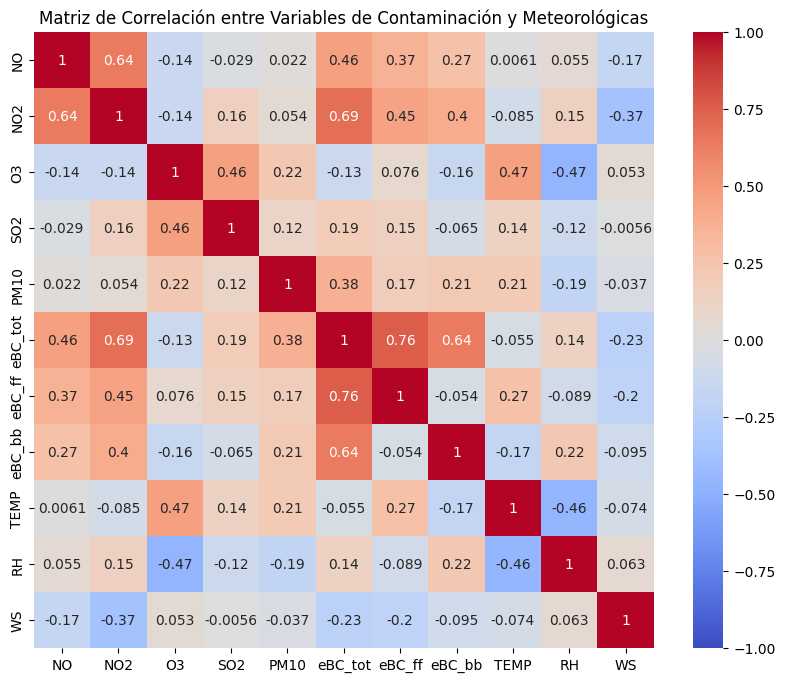

In [70]:
# Calcular la matriz de correlación
correlation_matrix = trafico_contamina_interseccion[['NO', 'NO2', 'O3', 'SO2', 'PM10', 'eBC_tot', 'eBC_ff', 'eBC_bb', 'TEMP', 'RH', 'WS']].corr()

# Mostrar la matriz
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Matriz de Correlación entre Variables de Contaminación y Meteorológicas')
plt.show()


## Mayores correlaciones

- **eBC_tot-eBC_ff** (0.76) y **eBC_tot-eBC_bb** (0.64):

Las correlaciones más fuertes en los datos de contaminación se observan entre eBC_tot y eBC_ff (0.76), y entre eBC_tot y eBC_bb (0.64). Esto sugiere que eBC_tot, que representa el hollín total, está compuesto principalmente por la fracción atribuible a la quema de combustibles fósiles (eBC_ff), pero también incluye una contribución significativa de la quema de biomasa (eBC_bb). La correlación más alta con eBC_ff indica que el tráfico y otras fuentes de combustibles fósiles son los mayores contribuyentes al black carbon total en la zona estudiada, mientras que la biomasa tiene una menor, pero importante, participación en las concentraciones generales de hollín.

- **NO2** y **eBC_tot** (0.69):

- TODO: **NO** y **NO2** (0.64)

Correlaciones negativas!!
- TODO: **RH** y **O3** 

## Preprocesamiento

### Imputación de datos faltantes con media y moda

In [71]:
# Imputar valores nulos en variables numéricas con la mediana
numeric_cols = trafico_contamina_interseccion.select_dtypes(include=['float64', 'int']).columns
trafico_contamina_interseccion[numeric_cols] = trafico_contamina_interseccion[numeric_cols].fillna(trafico_contamina_interseccion[numeric_cols].median())

# Imputar valores nulos en variables categóricas con la moda
categorical_cols = trafico_contamina_interseccion.select_dtypes(include=['object']).columns
for col in categorical_cols:
    trafico_contamina_interseccion[col] = trafico_contamina_interseccion[col].fillna(trafico_contamina_interseccion[col].mode()[0])  # Imputar con la moda


**TODO**: Interpolación con métodos numéricos

### Eliminación de Duplicados


In [72]:
trafico_contamina_interseccion.drop_duplicates(inplace=True)

In [73]:
## Esta variables es para dividir el dataset
## Dividir en dos escenarios
## Elaborar dos escenarios: (usar la variable truck_pos)
## 1) Pampaneira 
## 2) Capileira

## Escalado de datos

In [30]:
from sklearn.preprocessing import MinMaxScaler

numerical_cols = trafico_contamina_interseccion.select_dtypes(include=('float', 'int')).columns

# Escalar los datos
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(trafico_contamina_interseccion[numerical_cols])

# Convertir a DataFrame y combinar
data_scaled_df = pd.DataFrame(data_scaled, columns=numerical_cols)

# Combinar el DataFrame original (sin columnas numéricas) con el DataFrame escalado
result = pd.concat([trafico_contamina_interseccion.drop(columns=numerical_cols).reset_index(drop=True), 
                    data_scaled_df.reset_index(drop=True)], axis=1)

In [31]:
df_original = trafico_feb22_ago23
df_interseccion = result

df_interseccion["Date"]

0      2022-11-16 16:00:00
1      2022-11-16 17:00:00
2      2022-11-16 18:00:00
3      2022-11-16 19:00:00
4      2022-11-16 20:00:00
5      2022-11-16 21:00:00
6      2022-11-16 22:00:00
7      2022-11-16 23:00:00
8      2022-11-17 06:00:00
9      2022-11-17 07:00:00
10     2022-11-17 08:00:00
11     2022-11-17 09:00:00
               ...        
2165   2023-06-26 12:00:00
2166   2023-06-26 13:00:00
2167   2023-06-26 14:00:00
2168   2023-06-26 15:00:00
2169   2023-06-26 16:00:00
2170   2023-06-26 17:00:00
2171   2023-06-26 18:00:00
2172   2023-06-26 19:00:00
2173   2023-06-26 20:00:00
2174   2023-06-26 21:00:00
2175   2023-06-26 22:00:00
2176   2023-06-27 00:00:00
Name: Date, Length: 2177, dtype: datetime64[ns]

In [32]:
df_interseccion['Date'] = pd.to_datetime(df_interseccion['Date'])

df_interseccion['Date'] = df_interseccion['Date'].dt.tz_localize('UTC')


In [33]:
df_original["date"] = pd.to_datetime(df_original["date"])

In [34]:
df_original["date"] = df_original["date"].dt.tz_convert('UTC')

In [35]:
df_interseccion.rename(columns={'Date': 'date'}, inplace=True)

In [36]:
df_interseccion

,date,CO,NO2,NO,O3,SO2,PM10,eBC_tot,eBC_ff,eBC_bb,TEMP,RH,WS,WD,PRES,eBC,vehicles_PAM_1_OUT,vehicles_PAM_1_OUT_Zona_Granada,vehicles_PAM_1_OUT_Zona_Comunidad_de_Madrid,vehicles_PAM_1_OUT_Extranjero,vehicles_PAM_1_OUT_Zona_Andalucia_no_GR,vehicles_PAM_1_OUT_Zona_Catalunia_y_Otras,vehicles_PAM_1_OUT_Zona_Extremadura_y_Otras,vehicles_PAM_1_OUT_Zona_Otras,vehicles_PAM_1_OUT_5_seats,vehicles_PAM_1_OUT_nan_seats,vehicles_PAM_1_OUT_+5_seats,vehicles_PAM_1_OUT_-5_seats,vehicles_PAM_1_OUT_101-200_CO2,vehicles_PAM_1_OUT_nan_CO2,vehicles_PAM_1_OUT_+300_CO2,vehicles_PAM_1_OUT_0-100_CO2,vehicles_PAM_1_OUT_201-300_CO2,vehicles_PAM_1_OUT_Etiqueta C,vehicles_PAM_1_OUT_Sin Etiqueta,vehicles_PAM_1_OUT_Etiqueta B,vehicles_PAM_1_OUT_Etiqueta ECO,vehicles_PAM_1_OUT_Etiqueta 0,vehicles_PAM_1_IN,vehicles_PAM_1_IN_Zona_Granada,...,vehicles_BUB_OUT_Zona_Extremadura_y_Otras,vehicles_BUB_OUT_Zona_Otras,vehicles_BUB_OUT_5_seats,vehicles_BUB_OUT_nan_seats,vehicles_BUB_OUT_+5_seats,vehicles_BUB_OUT_-5_seats,vehicles_BUB_OUT_101-200_CO2,vehicles_BUB_OUT_nan_CO2,vehicles_BUB_OUT_+300_CO2,vehicles_BUB_OUT_0-100_CO2,vehicles_BUB_OUT_201-300_CO2,vehicles_BUB_OUT_Etiqueta C,vehicles_BUB_OUT_Sin Etiqueta,vehicles_BUB_OUT_Etiqueta B,vehicles_BUB_OUT_Etiqueta ECO,vehicles_BUB_OUT_Etiqueta 0,vehicles_BUB_IN,vehicles_BUB_IN_Zona_Granada,vehicles_BUB_IN_Zona_Comunidad_de_Madrid,vehicles_BUB_IN_Extranjero,vehicles_BUB_IN_Zona_Andalucia_no_GR,vehicles_BUB_IN_Zona_Catalunia_y_Otras,vehicles_BUB_IN_Zona_Extremadura_y_Otras,vehicles_BUB_IN_Zona_Otras,vehicles_BUB_IN_5_seats,vehicles_BUB_IN_nan_seats,vehicles_BUB_IN_+5_seats,vehicles_BUB_IN_-5_seats,vehicles_BUB_IN_101-200_CO2,vehicles_BUB_IN_nan_CO2,vehicles_BUB_IN_+300_CO2,vehicles_BUB_IN_0-100_CO2,vehicles_BUB_IN_201-300_CO2,vehicles_BUB_IN_Etiqueta C,vehicles_BUB_IN_Sin Etiqueta,vehicles_BUB_IN_Etiqueta B,vehicles_BUB_IN_Etiqueta ECO,vehicles_BUB_IN_Etiqueta 0,truck_pos_CAP,truck_pos_PAM_2
0,2022-11-16 16:00:00+00:00,0.345133,0.142857,0.024540,0.400826,0.413978,0.068464,0.078947,0.054054,0.045455,0.397059,0.581114,0.369722,0.395132,0.179894,0.129032,0.437500,0.586957,0.217391,0.12,0.176471,0.1875,0.384615,0.0,0.348837,0.125000,0.416667,0.6875,0.419355,0.392157,1.0,0.181818,0.0,0.384615,0.405405,0.363636,0.2,0.000000,0.152941,0.243243,...,0.10,0.0,0.190476,0.260870,0.1,0.307692,0.204545,0.261905,1.0,0.153846,0.00,0.195122,0.290323,0.142857,0.166667,0.333333,0.201550,0.235294,0.130435,0.333333,0.075472,0.071429,0.071429,0.0,0.184466,0.363636,0.076923,0.117647,0.153846,0.207547,0.5,0.266667,0.0,0.16,0.18750,0.195122,0.3,0.25,1.0,0.0
1,2022-11-16 17:00:00+00:00,0.442478,0.107143,0.006135,0.367769,0.413978,0.068464,0.026316,0.000000,0.045455,0.344118,0.846247,0.315139,0.436173,0.186949,0.129032,0.178571,0.173913,0.086957,0.24,0.058824,0.0625,0.076923,0.0,0.104651,0.250000,0.166667,0.1875,0.096774,0.196078,0.0,0.272727,0.2,0.134615,0.243243,0.060606,0.0,0.666667,0.135294,0.189189,...,0.00,0.0,0.079365,0.043478,0.0,0.000000,0.068182,0.047619,0.0,0.076923,0.00,0.048780,0.064516,0.035714,0.000000,0.333333,0.124031,0.156863,0.130435,0.250000,0.018868,0.000000,0.035714,0.0,0.116505,0.181818,0.076923,0.058824,0.092308,0.150943,0.0,0.066667,0.2,0.10,0.21875,0.073171,0.1,0.00,1.0,0.0
2,2022-11-16 18:00:00+00:00,0.256637,0.166667,0.036810,0.309917,0.413978,0.068464,0.157895,0.027027,0.227273,0.344118,0.855932,0.231720,0.465327,0.190476,0.129032,0.000000,0.000000,0.000000,0.00,0.000000,0.0000,0.000000,0.0,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,0.0,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,...,0.00,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.0,0.000000,0.00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.0,0.00,0.00000,0.000000,0.0,0.00,1.0,0.0
3,2022-11-16 19:00:00+00:00,0.230088,0.190476,0.049080,0.304752,0.413978,0.068464,0.236842,0.000000,0.409091,0.

In [37]:
df_original

,date,vehicles_CAP_OUT,vehicles_CAP_OUT_Zona_Granada,vehicles_CAP_OUT_Zona_Catalunia_y_Otras,vehicles_CAP_OUT_Zona_Andalucia_no_GR,vehicles_CAP_OUT_Extranjero,vehicles_CAP_OUT_Zona_Comunidad_de_Madrid,vehicles_CAP_OUT_Zona_Extremadura_y_Otras,vehicles_CAP_OUT_Zona_Otras,vehicles_CAP_OUT_5_seats,vehicles_CAP_OUT_+5_seats,vehicles_CAP_OUT_-5_seats,vehicles_CAP_OUT_nan_seats,vehicles_CAP_OUT_101-200_CO2,vehicles_CAP_OUT_0-100_CO2,vehicles_CAP_OUT_nan_CO2,vehicles_CAP_OUT_201-300_CO2,vehicles_CAP_OUT_+300_CO2,vehicles_CAP_IN,vehicles_CAP_IN_Zona_Granada,vehicles_CAP_IN_Zona_Catalunia_y_Otras,vehicles_CAP_IN_Zona_Andalucia_no_GR,vehicles_CAP_IN_Extranjero,vehicles_CAP_IN_Zona_Comunidad_de_Madrid,vehicles_CAP_IN_Zona_Extremadura_y_Otras,vehicles_CAP_IN_Zona_Otras,vehicles_CAP_IN_5_seats,vehicles_CAP_IN_+5_seats,vehicles_CAP_IN_-5_seats,vehicles_CAP_IN_nan_seats,vehicles_CAP_IN_101-200_CO2,vehicles_CAP_IN_0-100_CO2,vehicles_CAP_IN_nan_CO2,vehicles_CAP_IN_201-300_CO2,vehicles_CAP_IN_+300_CO2,vehicles_PAM_1_OUT,vehicles_PAM_1_OUT_Zona_Granada,vehicles_PAM_1_OUT_Zona_Catalunia_y_Otras,vehicles_PAM_1_OUT_Zona_Andalucia_no_GR,vehicles_PAM_1_OUT_Extranjero,...,vehicles_PAM_2_IN_nan_seats,vehicles_PAM_2_IN_101-200_CO2,vehicles_PAM_2_IN_0-100_CO2,vehicles_PAM_2_IN_nan_CO2,vehicles_PAM_2_IN_201-300_CO2,vehicles_PAM_2_IN_+300_CO2,vehicles_BUB_OUT,vehicles_BUB_OUT_Zona_Granada,vehicles_BUB_OUT_Zona_Catalunia_y_Otras,vehicles_BUB_OUT_Zona_Andalucia_no_GR,vehicles_BUB_OUT_Extranjero,vehicles_BUB_OUT_Zona_Comunidad_de_Madrid,vehicles_BUB_OUT_Zona_Extremadura_y_Otras,vehicles_BUB_OUT_Zona_Otras,vehicles_BUB_OUT_5_seats,vehicles_BUB_OUT_+5_seats,vehicles_BUB_OUT_-5_seats,vehicles_BUB_OUT_nan_seats,vehicles_BUB_OUT_101-200_CO2,vehicles_BUB_OUT_0-100_CO2,vehicles_BUB_OUT_nan_CO2,vehicles_BUB_OUT_201-300_CO2,vehicles_BUB_OUT_+300_CO2,vehicles_BUB_IN,vehicles_BUB_IN_Zona_Granada,vehicles_BUB_IN_Zona_Catalunia_y_Otras,vehicles_BUB_IN_Zona_Andalucia_no_GR,vehicles_BUB_IN_Extranjero,vehicles_BUB_IN_Zona_Comunidad_de_Madrid,vehicles_BUB_IN_Zona_Extremadura_y_Otras,vehicles_BUB_IN_Zona_Otras,vehicles_BUB_IN_5_seats,vehicles_BUB_IN_+5_seats,vehicles_BUB_IN_-5_seats,vehicles_BUB_IN_nan_seats,vehicles_BUB_IN_101-200_CO2,vehicles_BUB_IN_0-100_CO2,vehicles_BUB_IN_nan_CO2,vehicles_BUB_IN_201-300_CO2,vehicles_BUB_IN_+300_CO2
0,2022-02-04 12:00:00+00:00,23,11,1,2,5,2,2,0,12,1,5,5,6,1,15,1,0,22,11,3,6,0,0,2,0,17,3,2,0,12,2,8,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2022-02-04 13:00:00+00:00,25,11,1,4,7,2,0,0,10,5,3,7,7,1,16,1,0,43,17,1,16,4,3,2,0,36,0,4,3,16,4,23,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2022-02-04 14:00:00+00:00,32,20,1,6,4,1,0,0,23,3,2,4,13,2,17,0,0,39,14,2,10,7,3,3,0,21,6,6,6,12,2,25,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2022-02-04 15:00:00+00:00,32,20,1,6,2,2,1,0,24,4,2,2,9,4,19,0,0,26,10,1,2,7,3,3,0,15,2,2,7,7,3,16,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2022-02-04 16:00:00+00:00,30,11,1,8,3,3,4,0,22,2,3,3,13,4,13,0,0,21,11,1,5,2,2,0,0,14,1,4,2,5,5,11,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5,2022-02-04 17:00:00+00:00,25,13,0,6,3,3,0,0,18,2,3,2,7,2,15,1,0,29,17,0,6,2,2,2,0,24,1,2,2,10,2,16,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,2022-02-04 18:00:00+00:00,19,9,5,1,3,0,1,0,12,1,3,3,4,4,10,1,0,42,15,3,16,3,3,2,0,34,4,2,2,15,4,22,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
7,2022-02-04 19:00:00+00:00,9,7,1,0,0,1,0,0,3,2,4,0,3,3,3,0,0,24,10,0,7,4,1,2,0,16,1,3,4,8,3,13,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
8,2022-02-04 20:00:00+00:00,12,6,0,3,1,0,2,0,11,0,0,1,4,1,7,0,0,18,7,1,7,3,0,0,0,15,

## El conjunto intersección es un subconjunto del original

In [38]:
set(df_interseccion["date"]).issubset(set(df_original["date"]))

True

In [39]:
df_original[df_original["date"] == df_interseccion["date"][0]]

,date,vehicles_CAP_OUT,vehicles_CAP_OUT_Zona_Granada,vehicles_CAP_OUT_Zona_Catalunia_y_Otras,vehicles_CAP_OUT_Zona_Andalucia_no_GR,vehicles_CAP_OUT_Extranjero,vehicles_CAP_OUT_Zona_Comunidad_de_Madrid,vehicles_CAP_OUT_Zona_Extremadura_y_Otras,vehicles_CAP_OUT_Zona_Otras,vehicles_CAP_OUT_5_seats,vehicles_CAP_OUT_+5_seats,vehicles_CAP_OUT_-5_seats,vehicles_CAP_OUT_nan_seats,vehicles_CAP_OUT_101-200_CO2,vehicles_CAP_OUT_0-100_CO2,vehicles_CAP_OUT_nan_CO2,vehicles_CAP_OUT_201-300_CO2,vehicles_CAP_OUT_+300_CO2,vehicles_CAP_IN,vehicles_CAP_IN_Zona_Granada,vehicles_CAP_IN_Zona_Catalunia_y_Otras,vehicles_CAP_IN_Zona_Andalucia_no_GR,vehicles_CAP_IN_Extranjero,vehicles_CAP_IN_Zona_Comunidad_de_Madrid,vehicles_CAP_IN_Zona_Extremadura_y_Otras,vehicles_CAP_IN_Zona_Otras,vehicles_CAP_IN_5_seats,vehicles_CAP_IN_+5_seats,vehicles_CAP_IN_-5_seats,vehicles_CAP_IN_nan_seats,vehicles_CAP_IN_101-200_CO2,vehicles_CAP_IN_0-100_CO2,vehicles_CAP_IN_nan_CO2,vehicles_CAP_IN_201-300_CO2,vehicles_CAP_IN_+300_CO2,vehicles_PAM_1_OUT,vehicles_PAM_1_OUT_Zona_Granada,vehicles_PAM_1_OUT_Zona_Catalunia_y_Otras,vehicles_PAM_1_OUT_Zona_Andalucia_no_GR,vehicles_PAM_1_OUT_Extranjero,...,vehicles_PAM_2_IN_nan_seats,vehicles_PAM_2_IN_101-200_CO2,vehicles_PAM_2_IN_0-100_CO2,vehicles_PAM_2_IN_nan_CO2,vehicles_PAM_2_IN_201-300_CO2,vehicles_PAM_2_IN_+300_CO2,vehicles_BUB_OUT,vehicles_BUB_OUT_Zona_Granada,vehicles_BUB_OUT_Zona_Catalunia_y_Otras,vehicles_BUB_OUT_Zona_Andalucia_no_GR,vehicles_BUB_OUT_Extranjero,vehicles_BUB_OUT_Zona_Comunidad_de_Madrid,vehicles_BUB_OUT_Zona_Extremadura_y_Otras,vehicles_BUB_OUT_Zona_Otras,vehicles_BUB_OUT_5_seats,vehicles_BUB_OUT_+5_seats,vehicles_BUB_OUT_-5_seats,vehicles_BUB_OUT_nan_seats,vehicles_BUB_OUT_101-200_CO2,vehicles_BUB_OUT_0-100_CO2,vehicles_BUB_OUT_nan_CO2,vehicles_BUB_OUT_201-300_CO2,vehicles_BUB_OUT_+300_CO2,vehicles_BUB_IN,vehicles_BUB_IN_Zona_Granada,vehicles_BUB_IN_Zona_Catalunia_y_Otras,vehicles_BUB_IN_Zona_Andalucia_no_GR,vehicles_BUB_IN_Extranjero,vehicles_BUB_IN_Zona_Comunidad_de_Madrid,vehicles_BUB_IN_Zona_Extremadura_y_Otras,vehicles_BUB_IN_Zona_Otras,vehicles_BUB_IN_5_seats,vehicles_BUB_IN_+5_seats,vehicles_BUB_IN_-5_seats,vehicles_BUB_IN_nan_seats,vehicles_BUB_IN_101-200_CO2,vehicles_BUB_IN_0-100_CO2,vehicles_BUB_IN_nan_CO2,vehicles_BUB_IN_201-300_CO2,vehicles_BUB_IN_+300_CO2
4910,2022-11-16 16:00:00+00:00,23,12,2,6,0,1,2,0,17,3,3,0,9,3,10,0,1,22,13,2,2,1,2,2,0,17,3,1,1,12,4,6,0,0,49,27,3,6,3,...,5,21,2,22,1,0,23,9,1,5,6,0,2,0,12,1,4,6,9,2,11,0,1,26,12,1,4,4,3,2,0,19,1,2,4,10,4,11,0,1


A partir del elemento $4910$ se incluye el conjunto intersección en el original

In [40]:
df_original[df_original["date"] == list(reversed(df_interseccion["date"]))[0]]

,date,vehicles_CAP_OUT,vehicles_CAP_OUT_Zona_Granada,vehicles_CAP_OUT_Zona_Catalunia_y_Otras,vehicles_CAP_OUT_Zona_Andalucia_no_GR,vehicles_CAP_OUT_Extranjero,vehicles_CAP_OUT_Zona_Comunidad_de_Madrid,vehicles_CAP_OUT_Zona_Extremadura_y_Otras,vehicles_CAP_OUT_Zona_Otras,vehicles_CAP_OUT_5_seats,vehicles_CAP_OUT_+5_seats,vehicles_CAP_OUT_-5_seats,vehicles_CAP_OUT_nan_seats,vehicles_CAP_OUT_101-200_CO2,vehicles_CAP_OUT_0-100_CO2,vehicles_CAP_OUT_nan_CO2,vehicles_CAP_OUT_201-300_CO2,vehicles_CAP_OUT_+300_CO2,vehicles_CAP_IN,vehicles_CAP_IN_Zona_Granada,vehicles_CAP_IN_Zona_Catalunia_y_Otras,vehicles_CAP_IN_Zona_Andalucia_no_GR,vehicles_CAP_IN_Extranjero,vehicles_CAP_IN_Zona_Comunidad_de_Madrid,vehicles_CAP_IN_Zona_Extremadura_y_Otras,vehicles_CAP_IN_Zona_Otras,vehicles_CAP_IN_5_seats,vehicles_CAP_IN_+5_seats,vehicles_CAP_IN_-5_seats,vehicles_CAP_IN_nan_seats,vehicles_CAP_IN_101-200_CO2,vehicles_CAP_IN_0-100_CO2,vehicles_CAP_IN_nan_CO2,vehicles_CAP_IN_201-300_CO2,vehicles_CAP_IN_+300_CO2,vehicles_PAM_1_OUT,vehicles_PAM_1_OUT_Zona_Granada,vehicles_PAM_1_OUT_Zona_Catalunia_y_Otras,vehicles_PAM_1_OUT_Zona_Andalucia_no_GR,vehicles_PAM_1_OUT_Extranjero,...,vehicles_PAM_2_IN_nan_seats,vehicles_PAM_2_IN_101-200_CO2,vehicles_PAM_2_IN_0-100_CO2,vehicles_PAM_2_IN_nan_CO2,vehicles_PAM_2_IN_201-300_CO2,vehicles_PAM_2_IN_+300_CO2,vehicles_BUB_OUT,vehicles_BUB_OUT_Zona_Granada,vehicles_BUB_OUT_Zona_Catalunia_y_Otras,vehicles_BUB_OUT_Zona_Andalucia_no_GR,vehicles_BUB_OUT_Extranjero,vehicles_BUB_OUT_Zona_Comunidad_de_Madrid,vehicles_BUB_OUT_Zona_Extremadura_y_Otras,vehicles_BUB_OUT_Zona_Otras,vehicles_BUB_OUT_5_seats,vehicles_BUB_OUT_+5_seats,vehicles_BUB_OUT_-5_seats,vehicles_BUB_OUT_nan_seats,vehicles_BUB_OUT_101-200_CO2,vehicles_BUB_OUT_0-100_CO2,vehicles_BUB_OUT_nan_CO2,vehicles_BUB_OUT_201-300_CO2,vehicles_BUB_OUT_+300_CO2,vehicles_BUB_IN,vehicles_BUB_IN_Zona_Granada,vehicles_BUB_IN_Zona_Catalunia_y_Otras,vehicles_BUB_IN_Zona_Andalucia_no_GR,vehicles_BUB_IN_Extranjero,vehicles_BUB_IN_Zona_Comunidad_de_Madrid,vehicles_BUB_IN_Zona_Extremadura_y_Otras,vehicles_BUB_IN_Zona_Otras,vehicles_BUB_IN_5_seats,vehicles_BUB_IN_+5_seats,vehicles_BUB_IN_-5_seats,vehicles_BUB_IN_nan_seats,vehicles_BUB_IN_101-200_CO2,vehicles_BUB_IN_0-100_CO2,vehicles_BUB_IN_nan_CO2,vehicles_BUB_IN_201-300_CO2,vehicles_BUB_IN_+300_CO2
8701,2023-06-27 00:00:00+00:00,2,0,1,1,0,0,0,0,2,0,0,0,0,1,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


Hasta el elemento $8701$

Cada una de las columnas del dataset original está en el de intersección. Aunque este incluye algunas más (las de contaminación)

In [41]:
all(column in df_interseccion for column in df_original.columns)

True

In [87]:
columnas_int64 = df_original.select_dtypes(include='int64').columns

# Convertir esas columnas a float64
df_original[columnas_int64] = df_original[columnas_int64].astype('float64')

## Fusionar los dos conjuntos 

In [43]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

# Asegúrate de que no haya diferencias por espacios en blanco o tipo de datos
df_original[list(df_original.columns)] = df_original[list(df_original.columns)].apply(lambda x: x.str.strip() if x.dtype == "object" else x)
df_interseccion[list(df_original.columns)] = df_interseccion[list(df_original.columns)].apply(lambda x: x.str.strip() if x.dtype == "object" else x)


In [44]:
# Identificar las nuevas columnas que quieres rellenar
nuevas_columnas = df_interseccion.columns.difference(df_original.columns)

In [45]:
# TODO: El merge no rellena los valores

df = pd.merge(df_original, df_interseccion, how="left", on=list(df_original.columns))

In [46]:
fila_inicio = 4910
fila_final = 8701

# Reiniciar los índices para asegurar alineación
df_interseccion.reset_index(drop=True, inplace=True)
df.reset_index(drop=True, inplace=True)

# Comprobar la longitud de las filas seleccionadas
len_interseccion = len(df_interseccion)
len_merged = len(df)

if fila_inicio < len_merged:
    # Asegurarse de que las nuevas columnas existan en df_interseccion
    if all(col in df_interseccion.columns for col in nuevas_columnas):
        # Rellenar df_merged a partir de la fila 4910 con los valores de df_interseccion
        df.loc[fila_inicio:fila_final, nuevas_columnas] = df_interseccion.loc[0, nuevas_columnas].values
    else:
        print("Algunas nuevas columnas no existen en df_interseccion.")
else:
    print("No hay suficientes filas en df_interseccion o df_merged para realizar la operación.")


In [47]:
cols = ["date"]
cols.extend(nuevas_columnas)
df.loc[4905:4920, cols]

,date,CO,NO,NO2,O3,PM10,PRES,RH,SO2,TEMP,WD,WS,eBC,eBC_bb,eBC_ff,eBC_tot,truck_pos_CAP,truck_pos_PAM_2,vehicles_BUB_IN_Etiqueta 0,vehicles_BUB_IN_Etiqueta B,vehicles_BUB_IN_Etiqueta C,vehicles_BUB_IN_Etiqueta ECO,vehicles_BUB_IN_Sin Etiqueta,vehicles_BUB_OUT_Etiqueta 0,vehicles_BUB_OUT_Etiqueta B,vehicles_BUB_OUT_Etiqueta C,vehicles_BUB_OUT_Etiqueta ECO,vehicles_BUB_OUT_Sin Etiqueta,vehicles_CAP_IN_Etiqueta 0,vehicles_CAP_IN_Etiqueta B,vehicles_CAP_IN_Etiqueta C,vehicles_CAP_IN_Etiqueta ECO,vehicles_CAP_IN_Sin Etiqueta,vehicles_CAP_OUT_Etiqueta 0,vehicles_CAP_OUT_Etiqueta B,vehicles_CAP_OUT_Etiqueta C,vehicles_CAP_OUT_Etiqueta ECO,vehicles_CAP_OUT_Sin Etiqueta,vehicles_PAM_1_IN_Etiqueta 0,vehicles_PAM_1_IN_Etiqueta B,vehicles_PAM_1_IN_Etiqueta C,vehicles_PAM_1_IN_Etiqueta ECO,vehicles_PAM_1_IN_Sin Etiqueta,vehicles_PAM_1_OUT_Etiqueta 0,vehicles_PAM_1_OUT_Etiqueta B,vehicles_PAM_1_OUT_Etiqueta C,vehicles_PAM_1_OUT_Etiqueta ECO,vehicles_PAM_1_OUT_Sin Etiqueta,vehicles_PAM_2_IN_Etiqueta 0,vehicles_PAM_2_IN_Etiqueta B,vehicles_PAM_2_IN_Etiqueta C,vehicles_PAM_2_IN_Etiqueta ECO,vehicles_PAM_2_IN_Sin Etiqueta,vehicles_PAM_2_OUT_Etiqueta 0,vehicles_PAM_2_OUT_Etiqueta B,vehicles_PAM_2_OUT_Etiqueta C,vehicles_PAM_2_OUT_Etiqueta ECO,vehicles_PAM_2_OUT_Sin Etiqueta
4905,2022-11-16 11:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4906,2022-11-16 12:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4907,2022-11-16 13:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4908,2022-11-16 14:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4909,2022-11-16 15:00:00+00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4910,2022-11-16 16:00:00+00:00,0.345133,0.02454,0.142857,0.400826,0.068464,0.179894,0.581114,0.413978,0.397059,0.395132,0.369722,0.129032,0.045455,0.054054,0.078947,1.0,0.0,0.25,0.195122,0.16,0.3,0.1875,0.333333,0.142857,0.195122,0.166667,0.290323,0.0,0.146341,0.181818,0.076923,0.178571,0.333333,0.135135,0.170213,0.0,0.375,0.0,0.125,0.101266,0.153846,0.225,0.0,0.363636,0.384615,0.2,0.405405,0.0,0.27907,0.301887,0.125,0.548387,0.0,0.21875,0.208333,0.625,0.3
4911,2022-11-16 17:00:00+00:00,0.345133,0.02454,0.142857,0.400826,0.068464,0.179894,0.581114,0.413978,0.397059,0.395132,0.369722,0.129032,0.045455,0.054054,0.078947,1.0,0.0,0.25,0.195122,0.16,0.3,0.1875,0.333333,0.142857,0.195122,0.166667,0.290323,0.0,0.146341,0.181818,0.076923,0.178571,0.333333,0.135135,0.170213,0.0,0.375,0.0,0.125,0.101266,0.153846,0.225,0.0,0.363636,0.384615,0.2,0.405405,0.0,0.27907,0.301887,0.125,0.548387,0.0,0.21875,0.208333,0.625,0.3
4912,2022-11-16 18:00:00+00:00,0.345133,0.02454,0.142857,0.400826,0.068464,0.179894,0.581114,0.413978,0.397059,0.395132,0.369722,0.129032,0.045455,0.054054,0.078947,1.0,0.0,0.25,0.195122,0.16,0.3,0.1875,0.333333,0.142857,0.195122,0.166667,0.290323,0.0,0.146341,0.181818,0.076923,0.178571,0.333333,0.135135,0.170213,0.0,0.375,0.0,0.125,0.101266,0.153846,0.225,0.0,0.363636,0.384615,0.2,0.405405,0.0,0.27907,0.301887,0.125,0.548387,0.0,0.21875,0.208333,0.625,0.3
4913,2022-11-16 19:00:00+00:00,0.345133,0.02454

In [48]:
df.loc[8695:8710,cols]

,date,CO,NO,NO2,O3,PM10,PRES,RH,SO2,TEMP,WD,WS,eBC,eBC_bb,eBC_ff,eBC_tot,truck_pos_CAP,truck_pos_PAM_2,vehicles_BUB_IN_Etiqueta 0,vehicles_BUB_IN_Etiqueta B,vehicles_BUB_IN_Etiqueta C,vehicles_BUB_IN_Etiqueta ECO,vehicles_BUB_IN_Sin Etiqueta,vehicles_BUB_OUT_Etiqueta 0,vehicles_BUB_OUT_Etiqueta B,vehicles_BUB_OUT_Etiqueta C,vehicles_BUB_OUT_Etiqueta ECO,vehicles_BUB_OUT_Sin Etiqueta,vehicles_CAP_IN_Etiqueta 0,vehicles_CAP_IN_Etiqueta B,vehicles_CAP_IN_Etiqueta C,vehicles_CAP_IN_Etiqueta ECO,vehicles_CAP_IN_Sin Etiqueta,vehicles_CAP_OUT_Etiqueta 0,vehicles_CAP_OUT_Etiqueta B,vehicles_CAP_OUT_Etiqueta C,vehicles_CAP_OUT_Etiqueta ECO,vehicles_CAP_OUT_Sin Etiqueta,vehicles_PAM_1_IN_Etiqueta 0,vehicles_PAM_1_IN_Etiqueta B,vehicles_PAM_1_IN_Etiqueta C,vehicles_PAM_1_IN_Etiqueta ECO,vehicles_PAM_1_IN_Sin Etiqueta,vehicles_PAM_1_OUT_Etiqueta 0,vehicles_PAM_1_OUT_Etiqueta B,vehicles_PAM_1_OUT_Etiqueta C,vehicles_PAM_1_OUT_Etiqueta ECO,vehicles_PAM_1_OUT_Sin Etiqueta,vehicles_PAM_2_IN_Etiqueta 0,vehicles_PAM_2_IN_Etiqueta B,vehicles_PAM_2_IN_Etiqueta C,vehicles_PAM_2_IN_Etiqueta ECO,vehicles_PAM_2_IN_Sin Etiqueta,vehicles_PAM_2_OUT_Etiqueta 0,vehicles_PAM_2_OUT_Etiqueta B,vehicles_PAM_2_OUT_Etiqueta C,vehicles_PAM_2_OUT_Etiqueta ECO,vehicles_PAM_2_OUT_Sin Etiqueta
8695,2023-06-26 17:00:00+00:00,0.345133,0.02454,0.142857,0.400826,0.068464,0.179894,0.581114,0.413978,0.397059,0.395132,0.369722,0.129032,0.045455,0.054054,0.078947,1.0,0.0,0.25,0.195122,0.16,0.3,0.1875,0.333333,0.142857,0.195122,0.166667,0.290323,0.0,0.146341,0.181818,0.076923,0.178571,0.333333,0.135135,0.170213,0.0,0.375,0.0,0.125,0.101266,0.153846,0.225,0.0,0.363636,0.384615,0.2,0.405405,0.0,0.27907,0.301887,0.125,0.548387,0.0,0.21875,0.208333,0.625,0.3
8696,2023-06-26 18:00:00+00:00,0.345133,0.02454,0.142857,0.400826,0.068464,0.179894,0.581114,0.413978,0.397059,0.395132,0.369722,0.129032,0.045455,0.054054,0.078947,1.0,0.0,0.25,0.195122,0.16,0.3,0.1875,0.333333,0.142857,0.195122,0.166667,0.290323,0.0,0.146341,0.181818,0.076923,0.178571,0.333333,0.135135,0.170213,0.0,0.375,0.0,0.125,0.101266,0.153846,0.225,0.0,0.363636,0.384615,0.2,0.405405,0.0,0.27907,0.301887,0.125,0.548387,0.0,0.21875,0.208333,0.625,0.3
8697,2023-06-26 19:00:00+00:00,0.345133,0.02454,0.142857,0.400826,0.068464,0.179894,0.581114,0.413978,0.397059,0.395132,0.369722,0.129032,0.045455,0.054054,0.078947,1.0,0.0,0.25,0.195122,0.16,0.3,0.1875,0.333333,0.142857,0.195122,0.166667,0.290323,0.0,0.146341,0.181818,0.076923,0.178571,0.333333,0.135135,0.170213,0.0,0.375,0.0,0.125,0.101266,0.153846,0.225,0.0,0.363636,0.384615,0.2,0.405405,0.0,0.27907,0.301887,0.125,0.548387,0.0,0.21875,0.208333,0.625,0.3
8698,2023-06-26 20:00:00+00:00,0.345133,0.02454,0.142857,0.400826,0.068464,0.179894,0.581114,0.413978,0.397059,0.395132,0.369722,0.129032,0.045455,0.054054,0.078947,1.0,0.0,0.25,0.195122,0.16,0.3,0.1875,0.333333,0.142857,0.195122,0.166667,0.290323,0.0,0.146341,0.181818,0.076923,0.178571,0.333333,0.135135,0.170213,0.0,0.375,0.0,0.125,0.101266,0.153846,0.225,0.0,0.363636,0.384615,0.2,0.405405,0.0,0.27907,0.301887,0.125,0.548387,0.0,0.21875,0.208333,0.625,0.3
8699,2023-06-26 21:00:00+00:00,0.345133,0.02454,0.142857,0.400826,0.068464,0.179894,0.581114,0.413978,0.397059,0.395132,0.369722,0.129032,0.045455,0.054054,0.078947,1.0,0.0,0.25,0.195122,0.16,0.3,0.1875,0.333333,0.142857,0.195122,0.166667,0.290323,0.0,0.146341,0.181818,0.076923,0.178571,0.333333,0.135135,0.170213,0.0,0.375,0.0,0.125,0.101266,0.153846,0.225,0.0,0.363636,0.384615,0.2,0.405405,0.0,0.27907,0.301887,0.125,0.548387,0.0,0.21875,0.208333,0.625,0.3
8700,2023-06-26 22:00:00+00:00,0.345133,0.02454,0.142857,0.400826,0.068464,0.179894,0.581114,0.413978,0.397059,0.395132,0.369722,0.129032,0.045455,0.054054,0.078947,1.0,0.0,0.25,0.195122,0.16,0.3,0.1875,0.333333,0.142857,0.195122,0.166667,0.290323,0.0,0.146341,0.181818,0.076923,0.178571,0.333333,0.135135,0.170213,0.0,0.375,0.0,0.125,0.101266,0.153846,0.225,0.0,0.363636,0.384615,0.2,0.405405,0.0,0.27907,0.301887,0.125